<font color = green >

## Home Task

</font>

Apply various clustering algorithms 

- Agglomerative clustering using `complete` linkage 
- Agglomerative clustering using `single` linkage 
- DBSCAN
- Use albow method to determine the best k for Kmeans


<font color = green >

###  Data 

</font>



In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.cluster import (
    AgglomerativeClustering,
    DBSCAN,
    KMeans
)
from sklearn.datasets import make_blobs
# %matplotlib notebook

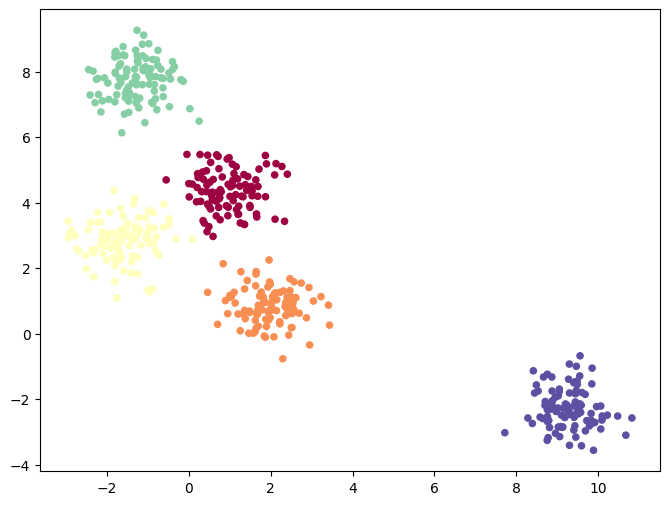

In [16]:
X, y = make_blobs(n_samples = 500, n_features = 2, centers = 5, 
                           cluster_std = 0.6, random_state = 0)
colors = np.array([plt.cm.Spectral(val)
          for val in np.linspace(0, 1, len(set(y)))])
plt.figure(figsize=(8,6))

plt.scatter(X[:,0], X[:,1], c= colors[y], s= 20)    

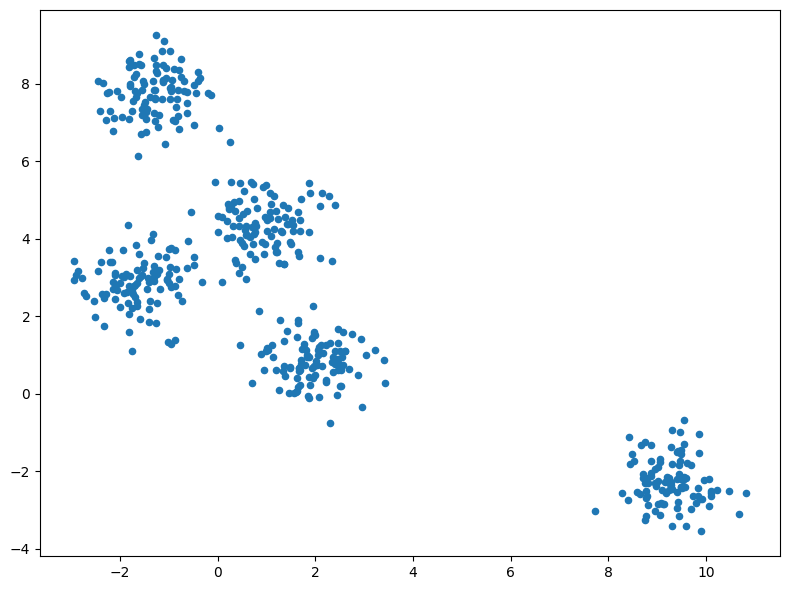

In [17]:
def plot_points(X, preds=None, centroids=None):
    ''' Func for ploting points, clusters and centroids'''
    if centroids is None:
        plt.figure(figsize=(8, 6))
        plt.scatter(X[:, 0], X[:, 1], c=preds, s=20)
    else:
        plt.figure(figsize=(8, 6))
        plt.scatter(X[:, 0], X[:, 1], c=preds, s=20)

        for c in centroids:
            plt.plot(c[0], c[1], marker='.', markersize=20, color='black' )
            
    plt.tight_layout()

plot_points(X) # from img we see possible 5 clusters

### Agglomerative clustering using `complete` linkage 

In [18]:
def agl_models(X, n_clasters=None, linkage=None):
    '''Func for implemet Agglomerative clustering'''

    agl_model = Pipeline(
        [
            ('scaler', StandardScaler()),
            ('model', AgglomerativeClustering(n_clusters=n_clasters, linkage=linkage))
        ]
    )

    print('Learning Sucsesfull')
    predict = agl_model.fit_predict(X)
    silhouette_metric = silhouette_score(X, predict) # measure of cohesion within a cluster and separation from neighboring ones
    
    return predict, silhouette_metric

Learning Sucsesfull
0.7158419658070393


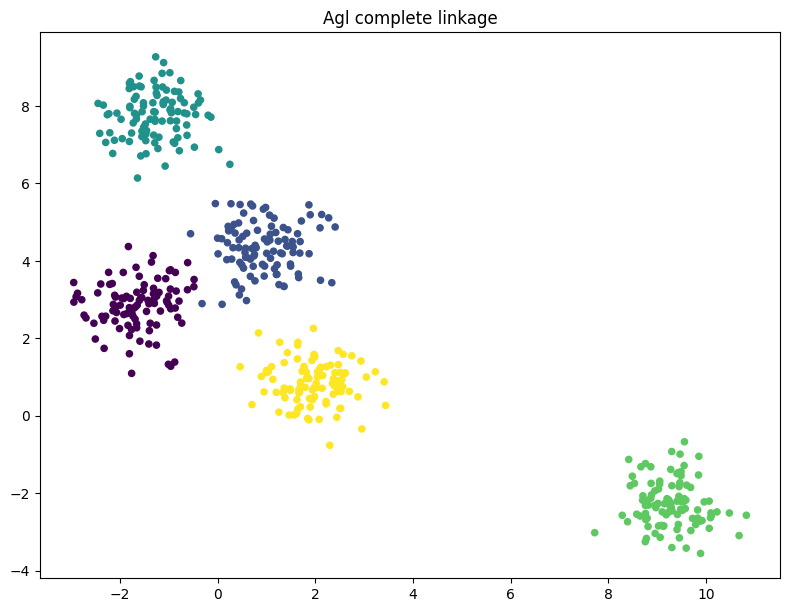

In [19]:
preds, silhouette= agl_models(X, n_clasters=5, linkage='complete')
plot_points(X, preds=preds)
plt.title('Agl complete linkage')

print(silhouette)

#### Denrogram with complete linkage

Text(0.5, 1.0, 'Dendrogram, linkage Complete')

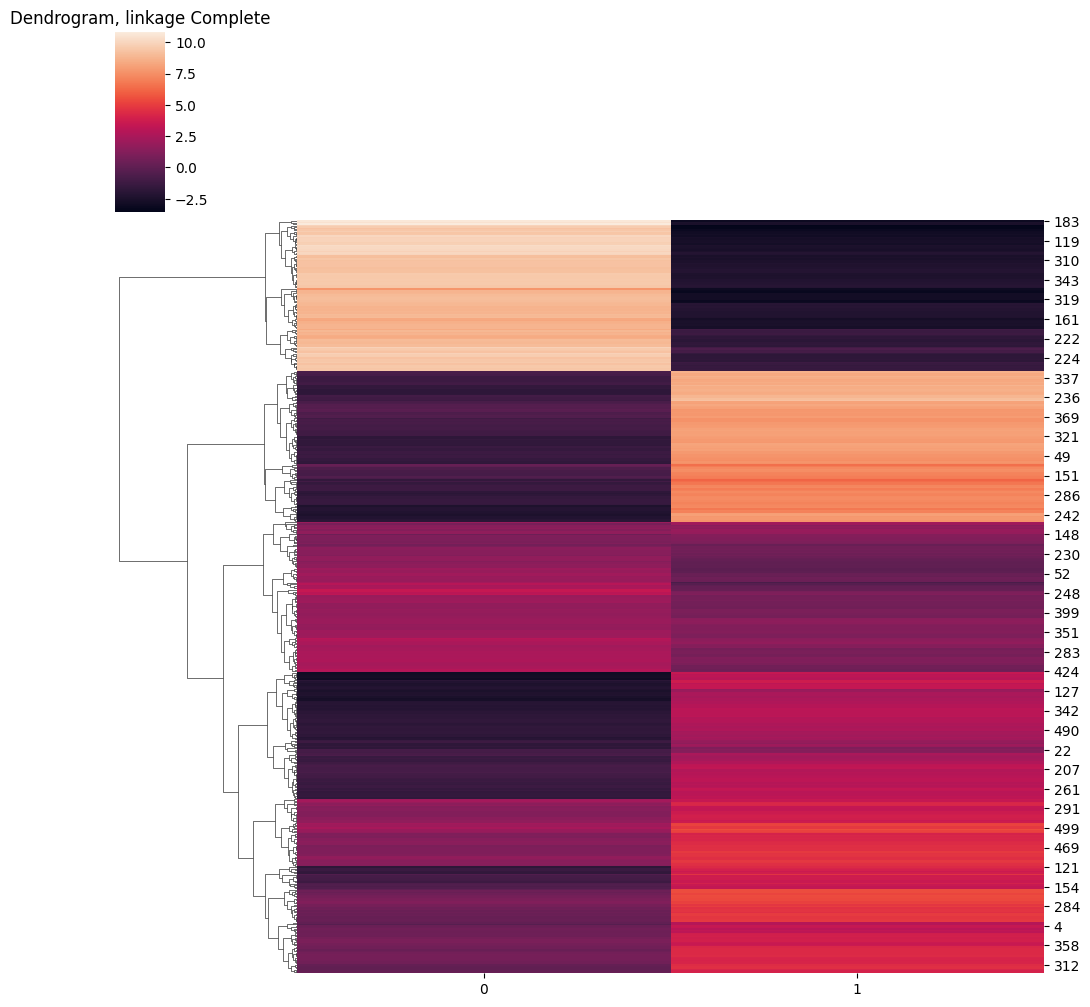

In [20]:
sns.clustermap(X, col_cluster=False, method='complete')
plt.title('Dendrogram, linkage Complete')

### Agglomerative clustering using `single` linkage

Learning Sucsesfull
0.5740226624379556


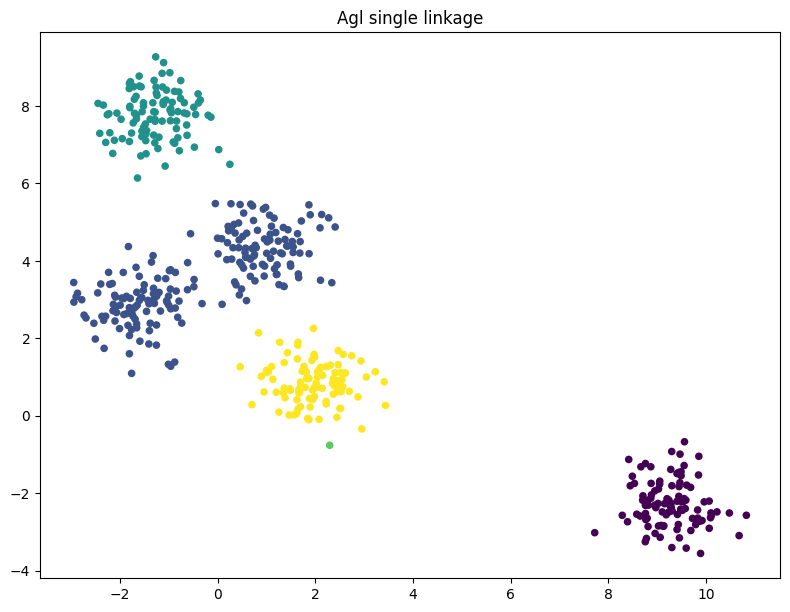

In [21]:
preds, silhouette = agl_models(X, n_clasters=5, linkage='single') # Using ready func
plot_points(X, preds=preds)
plt.title('Agl single linkage')

print(silhouette)

#### Dendrogram with single linkage

Text(0.5, 1.0, 'Dendrogram, linkage Single')

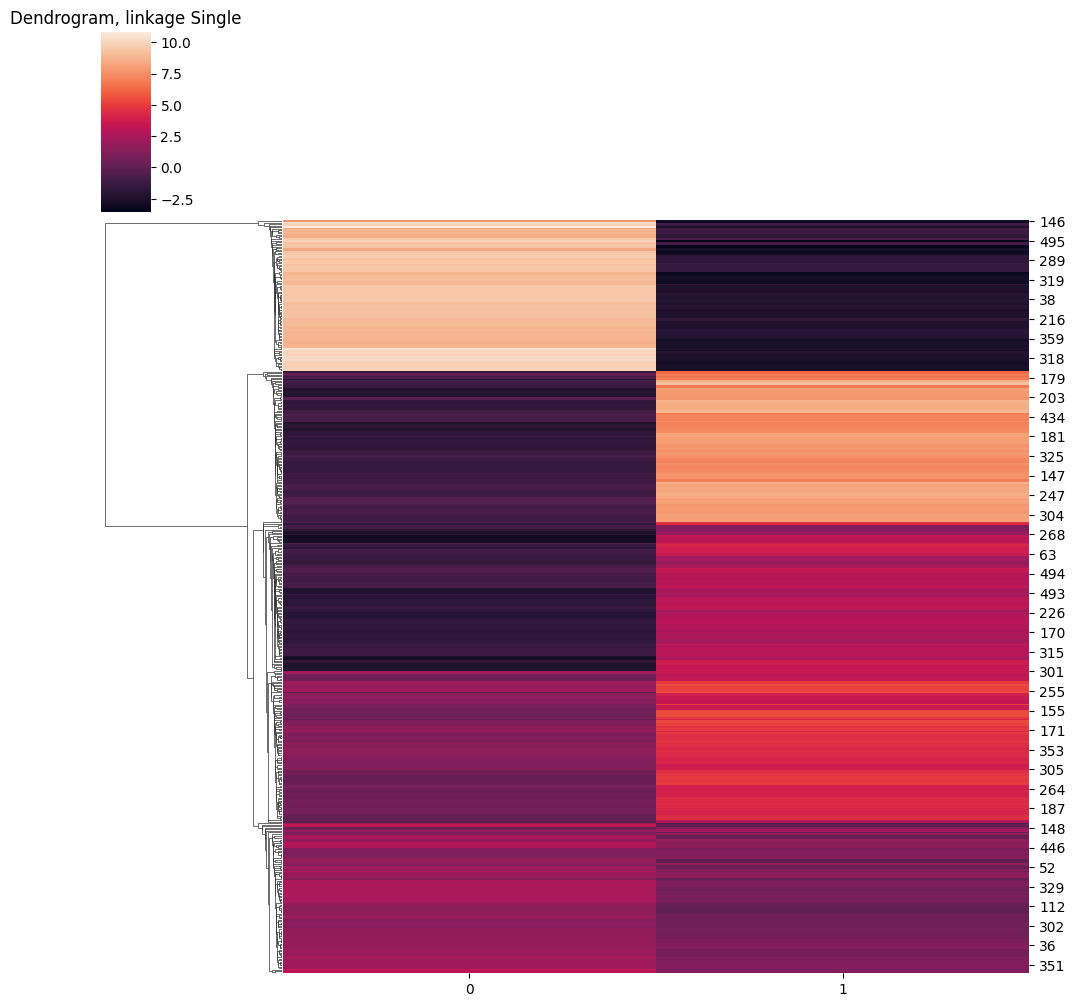

In [22]:
sns.clustermap(X, col_cluster=False, method='single')
plt.title('Dendrogram, linkage Single')

### DBSCAN

In [23]:
def dbscan(X, eps):
    clf = DBSCAN(eps, min_samples=4).fit(X)
    preds = clf.labels_
    n_clusters_and_noice = len(np.unique(preds))-1

    print(f'n_clusters_and_noice = {n_clusters_and_noice}')
    score = silhouette_score(X, preds)
    
    preds[np.where(preds == -1)] = n_clusters_and_noice
    return preds, score

n_clusters_and_noice = 5
0.6866707992096758


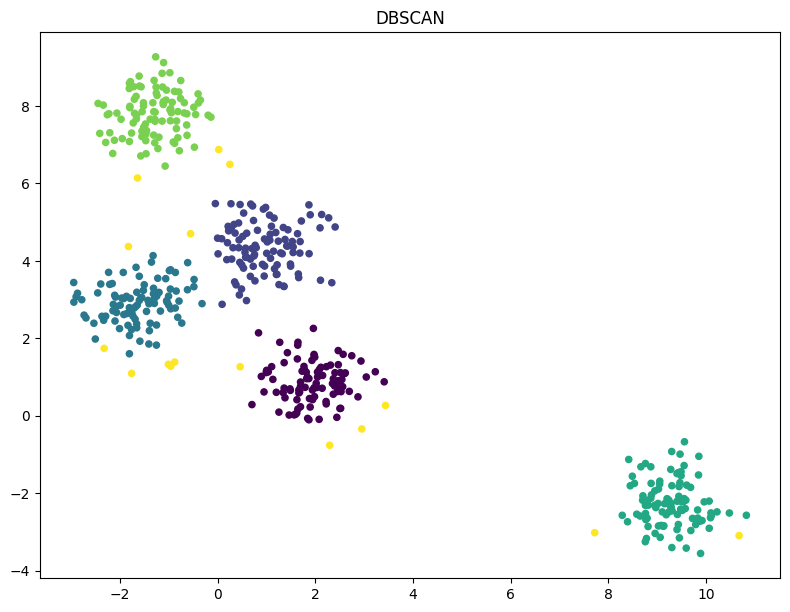

In [24]:
preds, score = dbscan(X, eps=0.5)

plot_points(X, preds)
plt.title('DBSCAN') # Yellow points its noise 
print(score)

### KMeans with eblow method

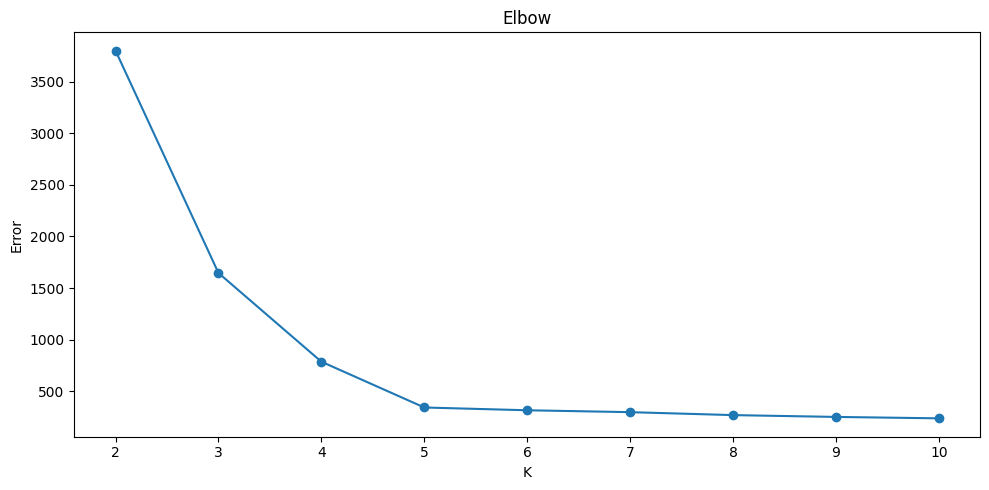

In [25]:
# Elbow Method
error = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(X)
    error.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))

plt.plot(K_range, error, marker='o')
plt.xlabel('K')
plt.ylabel('Error')
plt.title('Elbow')


plt.tight_layout()
plt.show()

Silhouette score: 0.7173660063213247


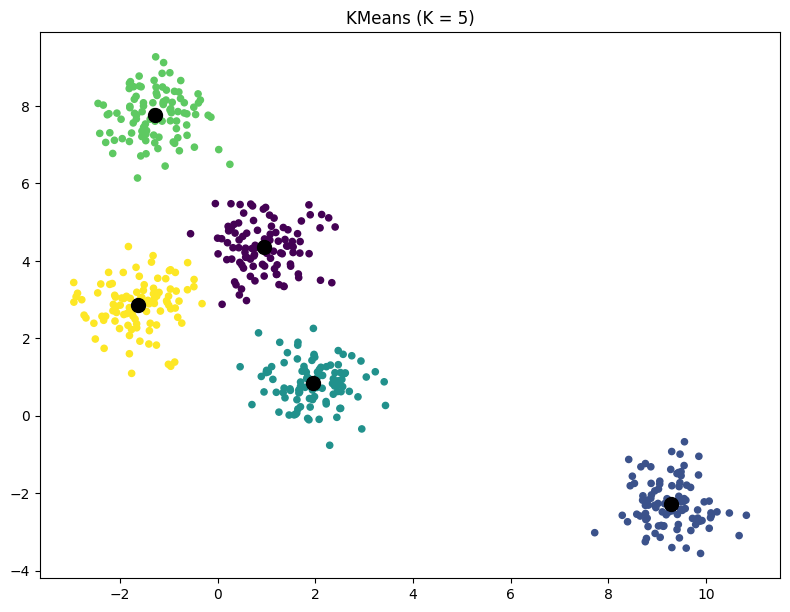

In [26]:
kmeans_model = KMeans(n_clusters=5).fit(X)
preds = kmeans_model.labels_
centroids = kmeans_model.cluster_centers_

plot_points(X, preds, centroids)
plt.title('KMeans (K = 5)')

print(f'Silhouette score: {silhouette_score(X, preds)}')